# Optional Crop of Prepared Images

This notebook is used only when the full prepared image does not need to be processed.

It should be run **after** the data-preparation step, where the satellite images and RPC metadata have already been organized in:

```text
merged_tiles/
```

The objective is to crop the prepared images to a smaller area of interest and save the results in:

```text
cropped_images/
```

The original files in `merged_tiles/` are not modified.

---

## Input files

For a stereo acquisition, the expected inputs are:

```text
merged_tiles/A.tif
merged_tiles/A.XML
merged_tiles/B.tif
merged_tiles/B.XML
```

For a tri-stereo acquisition, image `C` is also used:

```text
merged_tiles/C.tif
merged_tiles/C.XML
```

---

## Output files

The cropped outputs are saved as:

```text
cropped_images/A_crop.tif
cropped_images/A_crop.XML
cropped_images/B_crop.tif
cropped_images/B_crop.XML
```

For tri-stereo acquisitions, the output also includes:

```text
cropped_images/C_crop.tif
cropped_images/C_crop.XML
```

---

## Important note

After cropping, the RPC XML metadata must be updated because the image origin changes.

This notebook updates the RPC offsets:

```text
SAMP_OFF
LINE_OFF
```

Each cropped image must always be used with its matching cropped XML file.

Correct:

```text
A_crop.tif + A_crop.XML
```

Wrong:

```text
A_crop.tif + A.XML
```

The cropped images are still raw stereo images, not orthorectified images. Therefore, `A_crop`, `B_crop`, and `C_crop` may not look perfectly aligned when displayed directly. This is normal because the images were acquired from different viewing angles.

If the crop is too tight, increase:

```python
BUFFER_PX
```

In [1]:
# ============================================================
# 1. USER INPUTS
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# 1.1 Site and date
# ------------------------------------------------------------
Site_Name = "Berared"  #Berarde    Berared
Date = "Aug24"

# ------------------------------------------------------------
# 1.2 Select the project/sensor base directory
# ------------------------------------------------------------
# Activate only ONE option.

# Pléiades DINAMIS
base = Path(f"/mnt/summer/USERS/KOAI/{Site_Name}_{Date}")

# Pléiades Neo
# base = Path(f"/mnt/summer/USERS/KOAI/Pleiades_Neo_Analysis/{Site_Name}_{Date}")

# SPOT
# base = Path(f"/mnt/summer/USERS/KOAI/SPOT_Analysis/{Site_Name}_{Date}")

# Manual path
# base = Path("/mnt/summer/USERS/KOAI/My_Project/My_Site_Date")


# ------------------------------------------------------------
# 1.3 Input and output folders
# ------------------------------------------------------------
input_dir = base / "merged_tiles"
output_dir =  base / "merged_tiles" / "cropped_images"


# ------------------------------------------------------------
# 1.4 Acquisition mode
# ------------------------------------------------------------
# Options:
#   "stereo"      -> A and B
#   "tri_stereo"  -> A, B, and C

ACQUISITION_MODE = "tri_stereo"    #"tri_stereo"   "stereo" 


# ------------------------------------------------------------
# 1.5 AOI file used for cropping
# ------------------------------------------------------------
AOI_VECTOR = Path(
    "/mnt/summer/USERS/KOAI/Berared_Aug24/shapefile/Roughness_cross_section.shp"
)

# ------------------------------------------------------------
# 1.6 RPC crop parameters
# ------------------------------------------------------------
# Representative terrain elevation in metres
RPC_HEIGHT = 2500

# Extra buffer around the AOI in image pixels
BUFFER_PX = 500

# AOI boundary densification spacing in degrees
SPACING_DEG = 0.00005


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import shutil
import geopandas as gpd
import numpy as np
import rasterio

from rasterio.windows import Window
from xml.etree import ElementTree as ET
from rpcm.rpc_model import RPCModel


# ============================================================
# 3. AUTOMATIC SETTINGS AND BASIC CHECKS
# ============================================================

if ACQUISITION_MODE == "stereo":
    image_names = ["A", "B"]

elif ACQUISITION_MODE == "tri_stereo":
    image_names = ["A", "B", "C"]

else:
    raise ValueError("ACQUISITION_MODE must be 'stereo' or 'tri_stereo'.")


print("============================================================")
print("OPTIONAL CROP SETTINGS")
print("============================================================")
print(f"Site name        : {Site_Name}")
print(f"Date             : {Date}")
print(f"Base directory   : {base}")
print(f"Input directory  : {input_dir}")
print(f"Output directory : {output_dir}")
print(f"AOI vector       : {AOI_VECTOR}")
print(f"Acquisition mode : {ACQUISITION_MODE}")
print(f"Images to crop   : {image_names}")
print(f"RPC height       : {RPC_HEIGHT}")
print(f"Buffer pixels    : {BUFFER_PX}")
print(f"Spacing degrees  : {SPACING_DEG}")
print("============================================================")
print("")

if not input_dir.exists():
    raise FileNotFoundError(f"Input folder does not exist: {input_dir}")

if not AOI_VECTOR.exists():
    raise FileNotFoundError(f"AOI vector does not exist: {AOI_VECTOR}")

output_dir.mkdir(parents=True, exist_ok=True)

for name in image_names:
    img_path = input_dir / f"{name}.tif"
    rpc_path = input_dir / f"{name}.XML"

    if not img_path.exists():
        raise FileNotFoundError(f"Missing image file: {img_path}")

    if not rpc_path.exists():
        raise FileNotFoundError(f"Missing RPC XML file: {rpc_path}")

    print(f"{name}: input files found")
    print(f"  Image: {img_path}")
    print(f"  RPC  : {rpc_path}")

print("")
print("All input checks passed.")
print("")


# ============================================================
# 4. FUNCTIONS
# ============================================================

def load_rpc_from_xml(xml_path):
    """
    Load RPC coefficients from XML and return an RPCModel.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    rfm = root.find(".//Rational_Function_Model/Global_RFM")
    if rfm is None:
        raise ValueError(f"Cannot find Rational_Function_Model/Global_RFM in: {xml_path}")

    def get(tag):
        elem = rfm.find(f".//{tag}")
        if elem is None:
            raise ValueError(f"Missing RPC tag: {tag} in {xml_path}")
        return elem.text.strip()

    def coeffs(prefix):
        return " ".join(get(f"{prefix}_{i}") for i in range(1, 21))

    rpc_dict = {
        "LINE_OFF": get("LINE_OFF"),
        "SAMP_OFF": get("SAMP_OFF"),
        "LAT_OFF": get("LAT_OFF"),
        "LONG_OFF": get("LONG_OFF"),
        "HEIGHT_OFF": get("HEIGHT_OFF"),
        "LINE_SCALE": get("LINE_SCALE"),
        "SAMP_SCALE": get("SAMP_SCALE"),
        "LAT_SCALE": get("LAT_SCALE"),
        "LONG_SCALE": get("LONG_SCALE"),
        "HEIGHT_SCALE": get("HEIGHT_SCALE"),
        "LINE_NUM_COEFF": coeffs("LINE_NUM_COEFF"),
        "LINE_DEN_COEFF": coeffs("LINE_DEN_COEFF"),
        "SAMP_NUM_COEFF": coeffs("SAMP_NUM_COEFF"),
        "SAMP_DEN_COEFF": coeffs("SAMP_DEN_COEFF"),
    }

    return RPCModel(rpc_dict, dict_format="geotiff")


def update_rpc_offsets(in_xml, out_xml, col0, row0):
    """
    Update SAMP_OFF and LINE_OFF after cropping.
    """
    tree = ET.parse(in_xml)
    root = tree.getroot()

    samp = root.find(".//SAMP_OFF")
    line = root.find(".//LINE_OFF")

    if samp is None:
        raise ValueError(f"Missing SAMP_OFF in: {in_xml}")

    if line is None:
        raise ValueError(f"Missing LINE_OFF in: {in_xml}")

    samp.text = str(float(samp.text) - col0)
    line.text = str(float(line.text) - row0)

    out_xml = Path(out_xml)
    out_xml.parent.mkdir(parents=True, exist_ok=True)

    tree.write(out_xml, encoding="UTF-8", xml_declaration=True)


def densify_linestring(line, spacing_deg):
    """
    Densify a LineString geometry before RPC projection.
    """
    n_points = max(2, int(line.length / spacing_deg))

    points = [
        line.interpolate(i / (n_points - 1), normalized=True).coords[0]
        for i in range(n_points)
    ]

    return points


def extract_aoi_lonlat_points(vector_path, spacing_deg):
    """
    Read AOI vector and extract lon/lat boundary points.
    """
    gdf = gpd.read_file(vector_path)

    if gdf.empty:
        raise ValueError(f"AOI vector is empty: {vector_path}")

    gdf = gdf.to_crs("EPSG:4326")

    try:
        geom = gdf.geometry.union_all()
    except AttributeError:
        geom = gdf.geometry.unary_union

    points = []

    def add_geom_coords(g):
        if g.geom_type == "Polygon":
            points.extend(densify_linestring(g.exterior, spacing_deg))

        elif g.geom_type == "MultiPolygon":
            for part in g.geoms:
                points.extend(densify_linestring(part.exterior, spacing_deg))

        elif g.geom_type == "LineString":
            points.extend(densify_linestring(g, spacing_deg))

        elif g.geom_type == "MultiLineString":
            for part in g.geoms:
                points.extend(densify_linestring(part, spacing_deg))

        else:
            raise ValueError(f"Unsupported geometry type: {g.geom_type}")

    add_geom_coords(geom)

    if len(points) == 0:
        raise ValueError("No AOI points were extracted.")

    lons = [p[0] for p in points]
    lats = [p[1] for p in points]

    print(f"Number of AOI points used: {len(points)}")

    return lons, lats


def get_rpc_window(rpc_path, lons, lats, height, buffer_px):
    """
    Project AOI lon/lat points into image coordinates and compute crop window.
    """
    rpc = load_rpc_from_xml(rpc_path)

    heights = [height] * len(lons)
    cols, rows = rpc.projection(lons, lats, heights)

    col_min = int(np.floor(np.min(cols))) - buffer_px
    col_max = int(np.ceil(np.max(cols))) + buffer_px
    row_min = int(np.floor(np.min(rows))) - buffer_px
    row_max = int(np.ceil(np.max(rows))) + buffer_px

    return col_min, col_max, row_min, row_max


def crop_one_rpc_image(img_path, rpc_path, out_img_path, out_rpc_path, rpc_window):
    """
    Crop one image and write the updated RPC XML.
    """
    col_min, col_max, row_min, row_max = rpc_window

    img_path = Path(img_path)
    rpc_path = Path(rpc_path)
    out_img_path = Path(out_img_path)
    out_rpc_path = Path(out_rpc_path)

    out_img_path.parent.mkdir(parents=True, exist_ok=True)

    with rasterio.open(img_path) as src:
        col0 = max(0, col_min)
        row0 = max(0, row_min)
        col1 = min(src.width, col_max)
        row1 = min(src.height, row_max)

        width = col1 - col0
        height_crop = row1 - row0

        if width <= 0 or height_crop <= 0:
            raise ValueError(f"No overlap between AOI and image: {img_path}")

        window = Window(col0, row0, width, height_crop)

        data = src.read(window=window)
        transform = src.window_transform(window)

        meta = src.meta.copy()
        meta.update({
            "height": data.shape[1],
            "width": data.shape[2],
            "transform": transform
        })

    with rasterio.open(out_img_path, "w", **meta) as dst:
        dst.write(data)

    update_rpc_offsets(
        in_xml=rpc_path,
        out_xml=out_rpc_path,
        col0=col0,
        row0=row0
    )

    return col0, row0, width, height_crop


def copy_dim_metadata(input_dir, output_dir, image_name, out_name):
    """
    Copy DIM metadata if available.
    """
    src_dim = Path(input_dir) / f"DIM_{image_name}.XML"
    dst_dim = Path(output_dir) / f"DIM_{out_name}.XML"

    if src_dim.exists():
        shutil.copy2(src_dim, dst_dim)
        print(f"Copied DIM metadata: {dst_dim.name}")


def crop_rpc_images_by_aoi(
    aoi_vector,
    input_dir,
    output_dir,
    image_names,
    height,
    buffer_px,
    spacing_deg
):
    """
    Crop all selected prepared images and update their RPC XML files.
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    lons, lats = extract_aoi_lonlat_points(
        vector_path=aoi_vector,
        spacing_deg=spacing_deg
    )

    results = {}

    for name in image_names:
        img_path = input_dir / f"{name}.tif"
        rpc_path = input_dir / f"{name}.XML"

        out_name = f"{name}_crop"
        out_img_path = output_dir / f"{out_name}.tif"
        out_rpc_path = output_dir / f"{out_name}.XML"

        rpc_window = get_rpc_window(
            rpc_path=rpc_path,
            lons=lons,
            lats=lats,
            height=height,
            buffer_px=buffer_px
        )

        print("")
        print("------------------------------------------------------------")
        print(f"Cropping image: {name}")
        print("------------------------------------------------------------")
        print(f"Input image : {img_path}")
        print(f"Input RPC   : {rpc_path}")
        print(f"Output image: {out_img_path}")
        print(f"Output RPC  : {out_rpc_path}")
        print(f"RPC crop window before clipping: {rpc_window}")

        final_window = crop_one_rpc_image(
            img_path=img_path,
            rpc_path=rpc_path,
            out_img_path=out_img_path,
            out_rpc_path=out_rpc_path,
            rpc_window=rpc_window
        )

        copy_dim_metadata(
            input_dir=input_dir,
            output_dir=output_dir,
            image_name=name,
            out_name=out_name
        )

        results[name] = {
            "input_image": str(img_path),
            "input_rpc": str(rpc_path),
            "output_image": str(out_img_path),
            "output_rpc": str(out_rpc_path),
            "crop_window": final_window
        }

        print(f"Final crop window: {final_window}")

    return results


# ============================================================
# 5. RUN CROP
# ============================================================

crop_results = crop_rpc_images_by_aoi(
    aoi_vector=AOI_VECTOR,
    input_dir=input_dir,
    output_dir=output_dir,
    image_names=image_names,
    height=RPC_HEIGHT,
    buffer_px=BUFFER_PX,
    spacing_deg=SPACING_DEG
)


# ============================================================
# 6. FINAL CHECK
# ============================================================

print("")
print("============================================================")
print("CROP COMPLETED")
print("============================================================")
print(f"Cropped outputs saved in: {output_dir}")
print("")
print("Output files:")

for path in sorted(output_dir.glob("*")):
    print(f"  {path.name}")

print("")
print("Use these cropped files in the next ASP steps if cropping is needed:")
print(f"  {output_dir}/A_crop.tif")
print(f"  {output_dir}/A_crop.XML")
print(f"  {output_dir}/B_crop.tif")
print(f"  {output_dir}/B_crop.XML")

if ACQUISITION_MODE == "tri_stereo":
    print(f"  {output_dir}/C_crop.tif")
    print(f"  {output_dir}/C_crop.XML")

print("")
print("Otherwise, continue using the full prepared images:")
print(f"  {input_dir}/A.tif")
print(f"  {input_dir}/A.XML")
print(f"  {input_dir}/B.tif")
print(f"  {input_dir}/B.XML")

if ACQUISITION_MODE == "tri_stereo":
    print(f"  {input_dir}/C.tif")
    print(f"  {input_dir}/C.XML")

OPTIONAL CROP SETTINGS
Site name        : Berared
Date             : Aug24
Base directory   : /mnt/summer/USERS/KOAI/Berared_Aug24
Input directory  : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles
Output directory : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images
AOI vector       : /mnt/summer/USERS/KOAI/Berared_Aug24/shapefile/Roughness_cross_section.shp
Acquisition mode : tri_stereo
Images to crop   : ['A', 'B', 'C']
RPC height       : 2500
Buffer pixels    : 500
Spacing degrees  : 5e-05

A: input files found
  Image: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/A.tif
  RPC  : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/A.XML
B: input files found
  Image: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/B.tif
  RPC  : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/B.XML
C: input files found
  Image: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/C.tif
  RPC  : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/C.XML

All input checks passed.



ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.so.38: undefined symbol: sqlite3_total_changes64
ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.so.38: undefined symbol: sqlite3_total_changes64
ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.so.38: undefined symbol: sqlite3_total_changes64
ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.so.38: undefined symbol: sqlite3_total_changes64
ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.so.38: undefined symbol: sqlite3_total_changes64
ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.so.38: undefined symbol: sqlite3_total_changes64
ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.so.38: undefined symbol: sqlite3_total_changes64
ERROR 1: /workdir/hydrimz/koai/micromamba/envs/jupyter/lib/gdalplugins/../libgdal.s

Number of AOI points used: 903

------------------------------------------------------------
Cropping image: A
------------------------------------------------------------
Input image : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/A.tif
Input RPC   : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/A.XML
Output image: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.tif
Output RPC  : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/A_crop.XML
RPC crop window before clipping: (7137, 10111, 14173, 17394)
Copied DIM metadata: DIM_A_crop.XML
Final crop window: (7137, 14173, 2974, 3221)

------------------------------------------------------------
Cropping image: B
------------------------------------------------------------
Input image : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/B.tif
Input RPC   : /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/B.XML
Output image: /mnt/summer/USERS/KOAI/Berared_Aug24/merged_tiles/cropped_images/B_crop

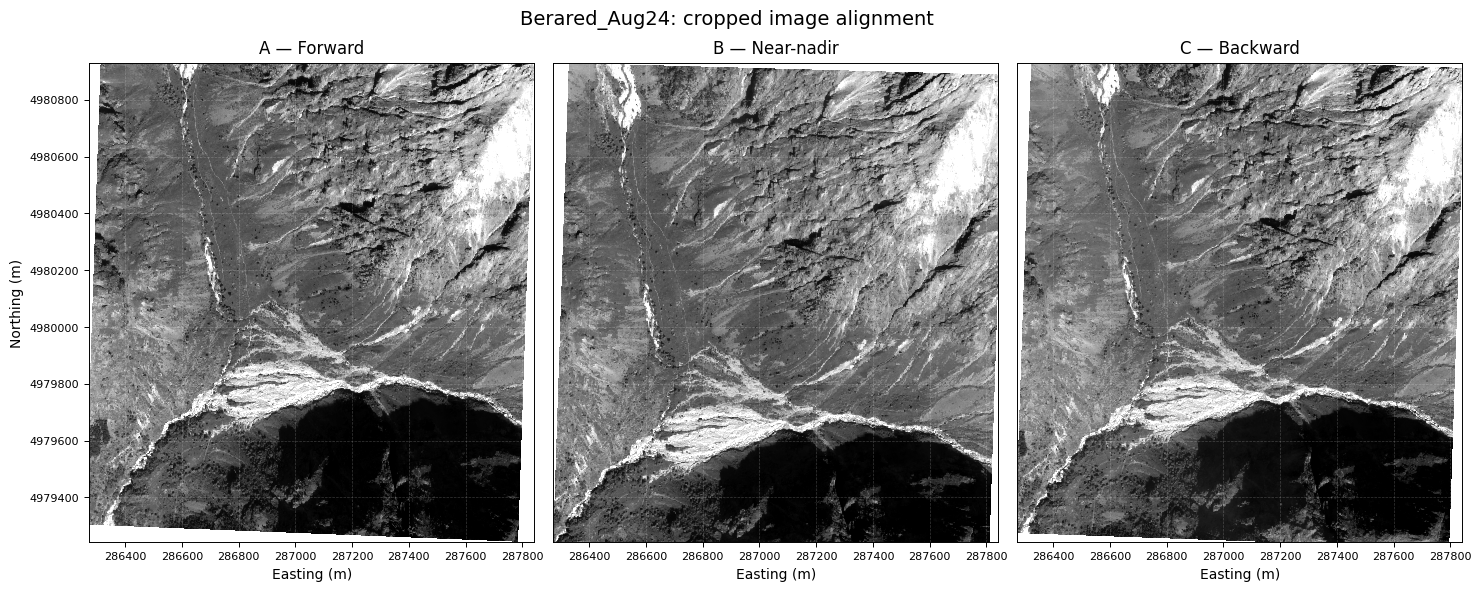

In [10]:
from importlib import reload
import asp_workflow_utils as asp_utils

reload(asp_utils)

asp_utils.plot_cropped_images(
    "Metadata-Copy1.sh",

    output_folder_name="Figure",

    show_grid=True,
    grid_color="white",
    grid_alpha=0.22,
    grid_linewidth=0.5,
    grid_linestyle="--",
    grid_spacing=None,

    return_images=False,
)